# Movie Recommendation System
This notebook processes the MovieLens dataset to clean data, perform EDA, and build a recommendation model.

In [1]:
import zipfile
import pandas as pd
import os

# Unzip the uploaded file
zip_path = '/content/ml-latest-small.zip'
extract_path = '/content/ml-latest-small'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# List files to verify contents
print("Extracted files:", os.listdir(extract_path))

Extracted files: ['README.txt', 'tags.csv', 'ratings.csv', 'links.csv', 'movies.csv']


In [2]:
# Load the datasets
movies = pd.read_csv(f'{extract_path}/movies.csv')
ratings = pd.read_csv(f'{extract_path}/ratings.csv')

# Basic cleaning: check for missing values
print("Missing values in Movies:\n", movies.isnull().sum())
print("\nMissing values in Ratings:\n", ratings.isnull().sum())

# Display first few rows
display(movies.head())
display(ratings.head())

Missing values in Movies:
 movieId    0
title      0
genres     0
dtype: int64

Missing values in Ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


## Exploratory Data Analysis (EDA)
Let's find the movies with the highest ratings and analyze the distribution.

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average rating and number of ratings per movie
movie_stats = ratings.groupby('movieId').agg({'rating': ['mean', 'count']})
movie_stats.columns = ['avg_rating', 'rating_count']

# Merge with movie titles
top_movies = movie_stats.merge(movies, on='movieId')

# Filter movies with a significant number of ratings (e.g., > 100) to find the 'highest rated'
highest_rated = top_movies[top_movies['rating_count'] > 100].sort_values(by='avg_rating', ascending=False)

print("Top 10 Highest Rated Movies (with over 100 ratings):")
display(highest_rated[['title', 'avg_rating', 'rating_count']].head(10))

Top 10 Highest Rated Movies (with over 100 ratings):


,title,avg_rating,rating_count
277,"Shawshank Redemption, The (1994)",4.429022,317
659,"Godfather, The (1972)",4.289062,192
2224,Fight Club (1999),4.272936,218
921,"Godfather: Part II, The (1974)",4.259690,129
6298,"Departed, The (2006)",4.252336,107
913,Goodfellas (1990),4.250000,126
6693,"Dark Knight, The (2008)",4.238255,149
46,"Usual Suspects, The (1995)",4.237745,204
898,"Princess Bride, The (1987)",4.232394,142
224,Star Wars: Episode IV - A New Hope (1977),4.231076,251


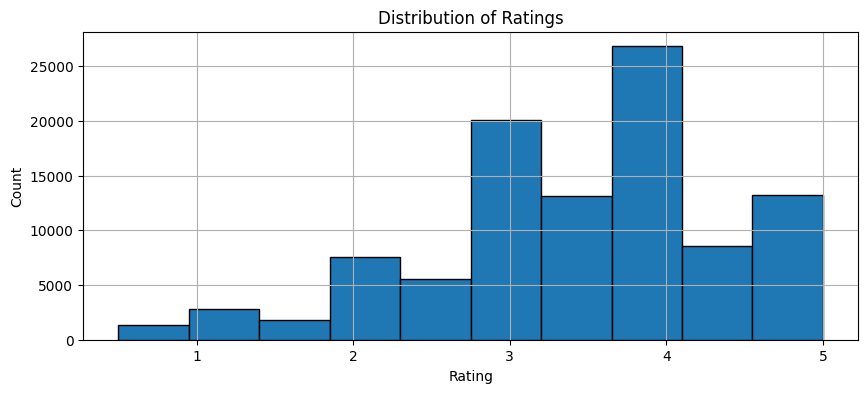

In [4]:
# Visualize the distribution of ratings
plt.figure(figsize=(10, 4))
ratings['rating'].hist(bins=10, edgecolor='black')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## Model Evaluation: Train-Test Split

In [5]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Split ratings into train and test (80% train, 20% test)
train_ratings, test_ratings = train_test_split(ratings, test_size=0.2, random_state=42)

# Create pivot table from training ratings only
train_features_df = train_ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)
train_features_matrix = csr_matrix(train_features_df.values)

# Re-fit our KNN model on training data
eval_model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
eval_model_knn.fit(train_features_matrix)

print(f"Training set shape: {train_ratings.shape}")
print(f"Test set shape: {test_ratings.shape}")

Training set shape: (80668, 4)
Test set shape: (20168, 4)


# Evaluating Predictions

In [6]:
def predict_rating(user_id, movie_id, n_neighbors=5):
    # If the movie or user is not in our training set, we return the global average as a fallback
    if movie_id not in train_features_df.index:
        return train_ratings['rating'].mean()
    if user_id not in train_features_df.columns:
        return train_ratings['rating'].mean()

    # Get index of the target movie
    movie_idx = train_features_df.index.get_loc(movie_id)

    # Find nearest neighbors to the target movie
    distances, indices = eval_model_knn.kneighbors(
        train_features_df.iloc[movie_idx, :].values.reshape(1, -1),
        n_neighbors=n_neighbors + 1
    )

    # Flat arrays
    distances = distances.flatten()[1:] # Exclude the movie itself
    indices = indices.flatten()[1:]

    # Retrieve ratings given by the user to these neighbor movies
    neighbor_ratings = []
    weights = []

    for i, idx in enumerate(indices):
        neighbor_movie_id = train_features_df.index[idx]
        user_rating = train_features_df.loc[neighbor_movie_id, user_id]

        # If the user has rated this neighbor movie
        if user_rating > 0:
            neighbor_ratings.append(user_rating)
            # Cosine distance = 1 - cosine similarity. Weight similarity highly.
            similarity = 1.0 - distances[i]
            weights.append(max(similarity, 1e-5))

    if not neighbor_ratings:
        # Fallback to the user's average rating or movie's average rating
        return train_ratings[train_ratings['movieId'] == movie_id]['rating'].mean()

    # Return weighted average of neighbor ratings
    return np.dot(neighbor_ratings, weights) / sum(weights)

# Evaluate on a sample of the test set to save computation time
test_sample = test_ratings.sample(n=500, random_state=42).copy()
test_sample['predicted_rating'] = test_sample.apply(
    lambda row: predict_rating(row['userId'], row['movieId']),
    axis=1
)

# Compute metrics
y_true = test_sample['rating']
y_pred = test_sample['predicted_rating'].fillna(train_ratings['rating'].mean())

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"Evaluation Metrics on Test Sample (500 ratings):")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Evaluation Metrics on Test Sample (500 ratings):
Mean Absolute Error (MAE): 0.7558
Root Mean Squared Error (RMSE): 0.9935


## Movie Recommendation Model
We will implement a collaborative filtering approach using the K-Nearest Neighbors (KNN) algorithm to recommend movies based on user rating similarities.

In [7]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

movie_features_df = ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)

# Convert the pivot table to a sparse matrix for memory efficiency
movie_features_matrix = csr_matrix(movie_features_df.values)

# Initialize and fit the KNN model using cosine similarity
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(movie_features_matrix)

def get_recommendations(movie_name, n_recommendations=5):
    # Search for the movie title in the database
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]

    if movie_matches.empty:
        print(f"Could not find any movies matching '{movie_name}'.")
        return

    # Select the first match found
    movie_id = movie_matches.iloc[0]['movieId']
    movie_title = movie_matches.iloc[0]['title']

    # Get the row index in the pivot table
    try:
        query_index = movie_features_df.index.get_loc(movie_id)
    except KeyError:
        print(f"Movie '{movie_title}' has no rating data available.")
        return

    # Find the nearest neighbors
    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    print(f"Recommendations for '{movie_title}':\n")
    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_title = movies[movies['movieId'] == rec_movie_id]['title'].values[0]
        print(f"{i}: {rec_title} (Distance: {distances.flatten()[i]:.3f})")

# Example usage:
get_recommendations('Toy Story')

Recommendations for 'Toy Story (1995)':

1: Toy Story 2 (1999) (Distance: 0.427)
2: Jurassic Park (1993) (Distance: 0.434)
3: Independence Day (a.k.a. ID4) (1996) (Distance: 0.436)
4: Star Wars: Episode IV - A New Hope (1977) (Distance: 0.443)
5: Forrest Gump (1994) (Distance: 0.453)


### Visualizing Similarity Distances
This plot shows how 'close' the recommended movies are to the input movie in the feature space.

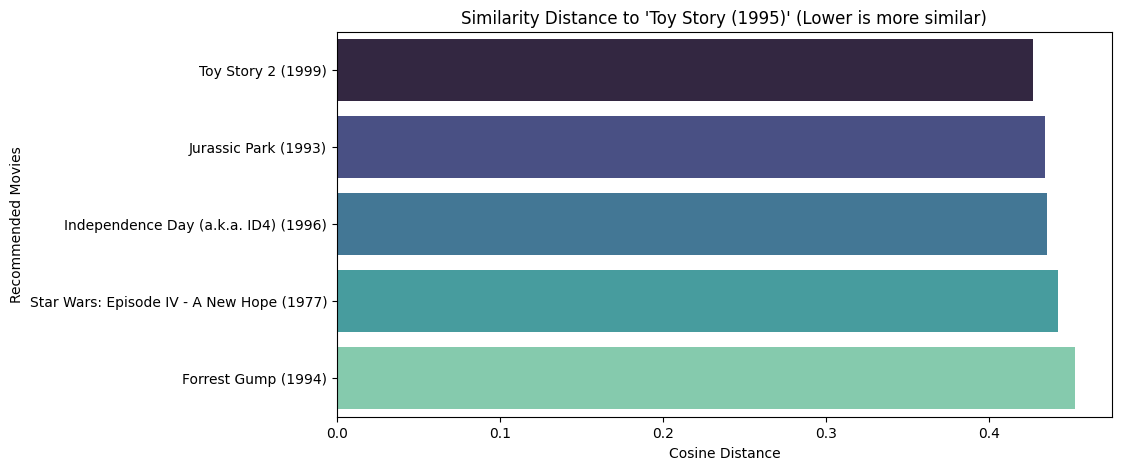

In [8]:
def plot_recommendation_distances(movie_name, n_recommendations=5):
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty: return

    movie_id = movie_matches.iloc[0]['movieId']
    query_index = movie_features_df.index.get_loc(movie_id)
    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    rec_titles = []
    rec_distances = []

    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_titles.append(movies[movies['movieId'] == rec_movie_id]['title'].values[0])
        rec_distances.append(distances.flatten()[i])

    plt.figure(figsize=(10, 5))
    # Fixed the palette warning by assigning hue to y
    sns.barplot(x=rec_distances, y=rec_titles, hue=rec_titles, palette='mako', legend=False)
    plt.title(f"Similarity Distance to '{movie_matches.iloc[0]['title']}' (Lower is more similar)")
    plt.xlabel('Cosine Distance')
    plt.ylabel('Recommended Movies')
    plt.show()

plot_recommendation_distances('Toy Story')

## Movie Recommendation Model
We will use a K-Nearest Neighbors (KNN) model based on user ratings to suggest similar movies.

In [9]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Create a pivot table: Rows are movies, columns are users, values are ratings
movie_features_df = ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)

# Convert to a sparse matrix for efficiency
movie_features_matrix = csr_matrix(movie_features_df.values)

# Fit the KNN model
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(movie_features_matrix)

def get_recommendations(movie_name, n_recommendations=5):
    # Find the movie ID
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty:
        return "Movie not found."

    # Use the first match
    movie_id = movie_matches.iloc[0]['movieId']
    movie_title = movie_matches.iloc[0]['title']

    # Get index in the pivot table
    try:
        query_index = movie_features_df.index.get_loc(movie_id)
    except KeyError:
        return "Movie ID not found in rating data."

    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    print(f"Recommendations for '{movie_title}':")
    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_title = movies[movies['movieId'] == rec_movie_id]['title'].values[0]
        print(f"{i}: {rec_title}")

# Test the recommender
get_recommendations('Fight Club')

Recommendations for 'Fight Club (1999)':
1: Matrix, The (1999)
2: Memento (2000)
3: American History X (1998)
4: Kill Bill: Vol. 1 (2003)
5: Lord of the Rings: The Fellowship of the Ring, The (2001)


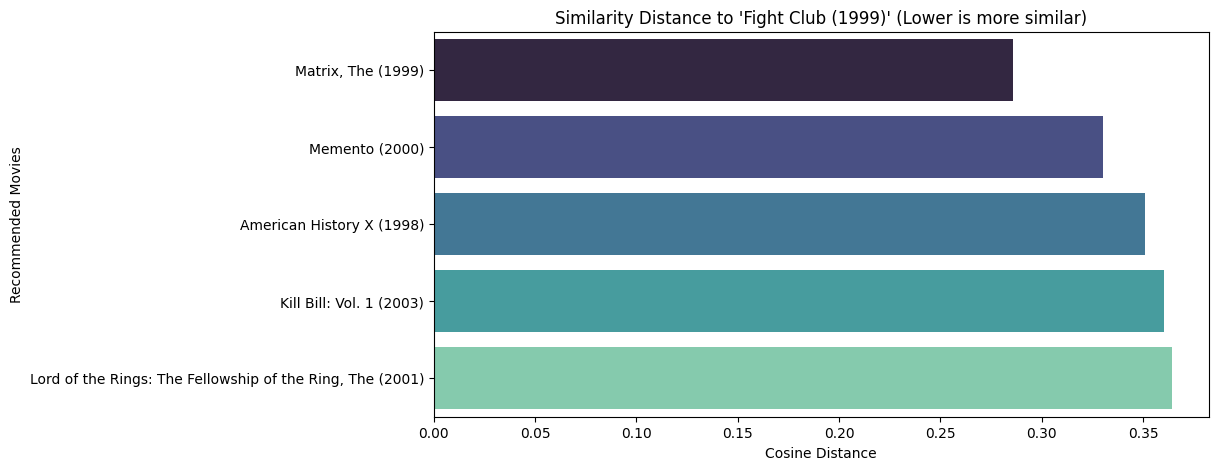

In [10]:
def plot_recommendation_distances(movie_name, n_recommendations=5):
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty: return

    movie_id = movie_matches.iloc[0]['movieId']
    query_index = movie_features_df.index.get_loc(movie_id)
    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    rec_titles = []
    rec_distances = []

    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_titles.append(movies[movies['movieId'] == rec_movie_id]['title'].values[0])
        rec_distances.append(distances.flatten()[i])

    plt.figure(figsize=(10, 5))
    # Fixed the palette warning by assigning hue to y
    sns.barplot(x=rec_distances, y=rec_titles, hue=rec_titles, palette='mako', legend=False)
    plt.title(f"Similarity Distance to '{movie_matches.iloc[0]['title']}' (Lower is more similar)")
    plt.xlabel('Cosine Distance')
    plt.ylabel('Recommended Movies')
    plt.show()

plot_recommendation_distances('Fight Club')

In [11]:
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# Create a pivot table: Rows are movies, columns are users, values are ratings
movie_features_df = ratings.pivot(index='movieId', columns='userId', values='rating').fillna(0)

# Convert to a sparse matrix for efficiency
movie_features_matrix = csr_matrix(movie_features_df.values)

# Fit the KNN model
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(movie_features_matrix)

def get_recommendations(movie_name, n_recommendations=5):
    # Find the movie ID
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty:
        return "Movie not found."

    # Use the first match
    movie_id = movie_matches.iloc[0]['movieId']
    movie_title = movie_matches.iloc[0]['title']

    # Get index in the pivot table
    try:
        query_index = movie_features_df.index.get_loc(movie_id)
    except KeyError:
        return "Movie ID not found in rating data."

    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    print(f"Recommendations for '{movie_title}':")
    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_title = movies[movies['movieId'] == rec_movie_id]['title'].values[0]
        print(f"{i}: {rec_title}")

# Test the recommender
get_recommendations('Dark Knight')

Recommendations for 'Dark Knight, The (2008)':
1: Inception (2010)
2: Iron Man (2008)
3: Dark Knight Rises, The (2012)
4: Batman Begins (2005)
5: Lord of the Rings: The Return of the King, The (2003)


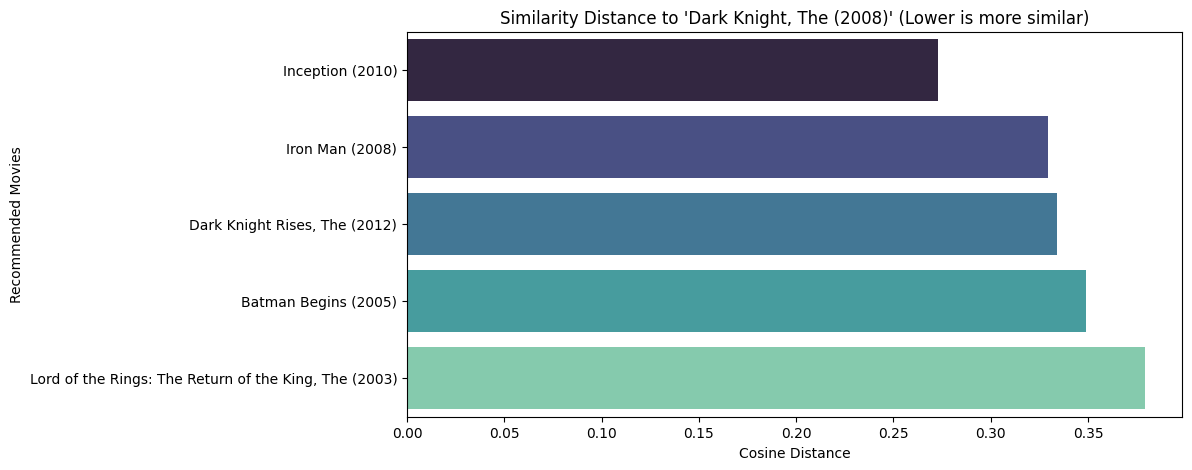

In [12]:
def plot_recommendation_distances(movie_name, n_recommendations=5):
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty: return

    movie_id = movie_matches.iloc[0]['movieId']
    query_index = movie_features_df.index.get_loc(movie_id)
    distances, indices = model_knn.kneighbors(movie_features_df.iloc[query_index, :].values.reshape(1, -1), n_neighbors=n_recommendations+1)

    rec_titles = []
    rec_distances = []

    for i in range(1, len(distances.flatten())):
        rec_movie_id = movie_features_df.index[indices.flatten()[i]]
        rec_titles.append(movies[movies['movieId'] == rec_movie_id]['title'].values[0])
        rec_distances.append(distances.flatten()[i])

    plt.figure(figsize=(10, 5))
    # Fixed the palette warning by assigning hue to y
    sns.barplot(x=rec_distances, y=rec_titles, hue=rec_titles, palette='mako', legend=False)
    plt.title(f"Similarity Distance to '{movie_matches.iloc[0]['title']}' (Lower is more similar)")
    plt.xlabel('Cosine Distance')
    plt.ylabel('Recommended Movies')
    plt.show()

plot_recommendation_distances('Dark Knight')

##Matrix Factorization (SVD)
We will implement a Matrix Factorization recommendation model using Singular Value Decomposition (SVD). SVD decomposes the user-item rating matrix into low-rank user and item embeddings, allowing us to capture latent factors and predict missing ratings.

In [13]:
from scipy.sparse.linalg import svds

# 1. Prepare user-item matrix for training
# We will use the training features pivot table (users as columns, movies as rows)
# Let's fill missing ratings with the average rating of each movie to keep the SVD stable

train_matrix_df = train_ratings.pivot(index='userId', columns='movieId', values='rating')
user_ratings_mean = train_matrix_df.mean(axis=1)
train_matrix_normalized = train_matrix_df.sub(user_ratings_mean, axis=0).fillna(0)

# 2. Apply Singular Value Decomposition (SVD)
# k is the number of latent factors
k = 20
U, sigma, Vt = svds(train_matrix_normalized.values, k=k)
sigma = np.diag(sigma)

# Reconstruct the predicted ratings
predicted_ratings_matrix = np.dot(np.dot(U, sigma), Vt) + user_ratings_mean.values.reshape(-1, 1)
predicted_ratings_df = pd.DataFrame(predicted_ratings_matrix, columns=train_matrix_df.columns, index=train_matrix_df.index)

print("SVD Model Matrix Factorization completed successfully.")

SVD Model Matrix Factorization completed successfully.


### Evaluating and Comparing Both Models
Now, we will evaluate the SVD model on the same 500-sample test set used for KNN and compare their evaluation metrics (MAE & RMSE).

In [14]:
def predict_svd_rating(user_id, movie_id):
    # Fallback to overall mean if user or movie is unseen
    global_mean = train_ratings['rating'].mean()
    if user_id not in predicted_ratings_df.index:
        return global_mean
    if movie_id not in predicted_ratings_df.columns:
        return global_mean

    val = predicted_ratings_df.loc[user_id, movie_id]
    # Clip predictions to valid rating bounds
    return np.clip(val, 0.5, 5.0)

# Predict using the SVD model on the same sample
test_sample['svd_predicted_rating'] = test_sample.apply(
    lambda row: predict_svd_rating(row['userId'], row['movieId']),
    axis=1
)

# Compute SVD metrics
y_pred_svd = test_sample['svd_predicted_rating'].fillna(train_ratings['rating'].mean())
rmse_svd = np.sqrt(mean_squared_error(y_true, y_pred_svd))
mae_svd = mean_absolute_error(y_true, y_pred_svd)

# Create a comparison table
comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'KNN Model': [mae, rmse],
    'SVD (Matrix Factorization)': [mae_svd, rmse_svd]
})

display(comparison_df)

,Metric,KNN Model,SVD (Matrix Factorization)
0,MAE,0.755788,0.741560
1,RMSE,0.993508,0.936879


## Movie Recommendations and Visualizations using SVD
SVD to calculate similarities between movies and suggest recommendations.

In [16]:
from sklearn.metrics.pairwise import cosine_similarity

svd_movie_features = predicted_ratings_df.T
svd_similarity_matrix = cosine_similarity(svd_movie_features)
svd_similarity_df = pd.DataFrame(svd_similarity_matrix, index=predicted_ratings_df.columns, columns=predicted_ratings_df.columns)

def get_svd_recommendations(movie_name, n_recommendations=5):
    # Find the movie ID
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty:
        print("Movie not found.")
        return

    # Use the first match
    movie_id = movie_matches.iloc[0]['movieId']
    movie_title = movie_matches.iloc[0]['title']

    if movie_id not in svd_similarity_df.index:
        print("Movie ID not found in rating data.")
        return

    # Get similarity scores for this movie
    sim_scores = svd_similarity_df[movie_id].sort_values(ascending=False)

    # Get top recommendations (exclude the movie itself, which has similarity 1.0)
    top_rec_ids = sim_scores.index[1:n_recommendations+1]

    print(f"SVD Recommendations for '{movie_title}':")
    for i, rec_id in enumerate(top_rec_ids, 1):
        rec_title = movies[movies['movieId'] == rec_id]['title'].values[0]
        similarity = sim_scores[rec_id]
        print(f"{i}: {rec_title} (Cosine Similarity: {similarity:.3f})")

# Test the SVD recommender
get_svd_recommendations('Dark Knight')

SVD Recommendations for 'Dark Knight, The (2008)':
1: WALL·E (2008) (Cosine Similarity: 0.999)
2: Lost in Translation (2003) (Cosine Similarity: 0.999)
3: In Bruges (2008) (Cosine Similarity: 0.999)
4: Kiss Kiss Bang Bang (2005) (Cosine Similarity: 0.999)
5: Hot Fuzz (2007) (Cosine Similarity: 0.999)


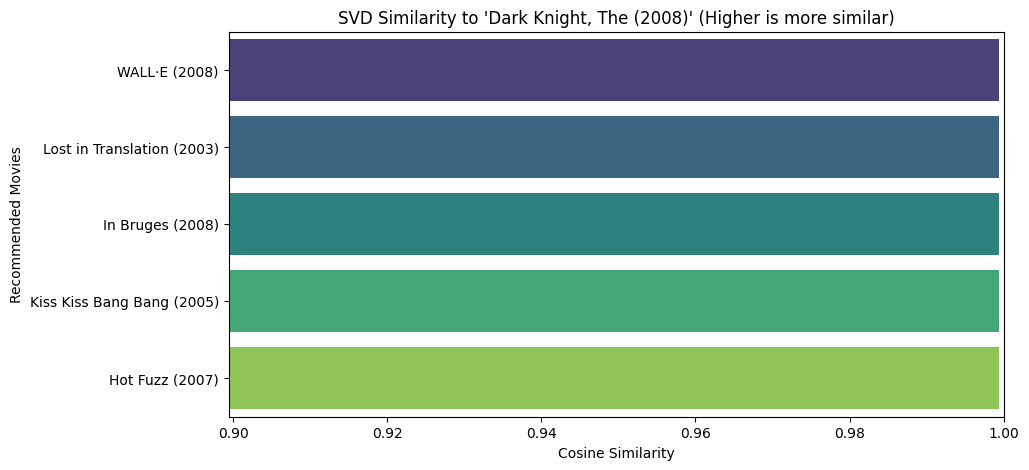

In [17]:
def plot_svd_recommendation_distances(movie_name, n_recommendations=5):
    movie_matches = movies[movies['title'].str.contains(movie_name, case=False)]
    if movie_matches.empty: return

    movie_id = movie_matches.iloc[0]['movieId']
    if movie_id not in svd_similarity_df.index: return

    sim_scores = svd_similarity_df[movie_id].sort_values(ascending=False)
    top_rec_ids = sim_scores.index[1:n_recommendations+1]

    rec_titles = []
    rec_similarities = []

    for rec_id in top_rec_ids:
        rec_titles.append(movies[movies['movieId'] == rec_id]['title'].values[0])
        rec_similarities.append(sim_scores[rec_id])

    plt.figure(figsize=(10, 5))
    sns.barplot(x=rec_similarities, y=rec_titles, hue=rec_titles, palette='viridis', legend=False)
    plt.title(f"SVD Similarity to '{movie_matches.iloc[0]['title']}' (Higher is more similar)")
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Recommended Movies')
    plt.xlim(max(0, min(rec_similarities) - 0.1), 1.0)
    plt.show()

plot_svd_recommendation_distances('Dark Knight')

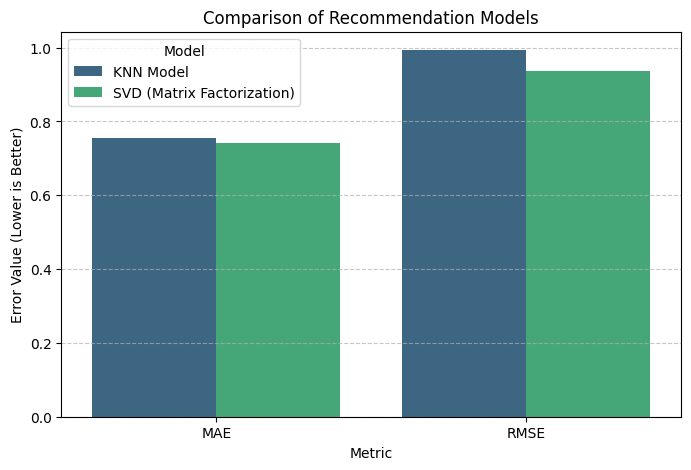

In [18]:
# Visualize the model comparison
plt.figure(figsize=(8, 5))
comparison_melted = pd.melt(comparison_df, id_vars=['Metric'], var_name='Model', value_name='Value')
sns.barplot(x='Metric', y='Value', hue='Model', data=comparison_melted, palette='viridis')
plt.title('Comparison of Recommendation Models')
plt.ylabel('Error Value (Lower is Better)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()